<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Bootstrap_agregation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Bootstraping_Aggregation(Bagging)->

# Dataset -> Braking into multiple sample and build individual models on those on those sample
# At last take voting or average of the models prediction

#Bagging create several sample by sampling row with replacemnt

#Each mosel/trees uses all the avlable features with while deciding split

In [ ]:
# ID      Feature
#  1         A
#  2         B
#  3         C
#  4         D
#  5         E
# S1 -> ID [2,5,1,5,4]
# S2 -> ID [3,1,2,2,4]
# S3 -> ID [5,5,4,1,3]
# i) Some rows will repeat
# ii) Some rows disappear

In [ ]:
# Dataset Link -> https://drive.google.com/file/d/1RCqWuPo-xUOhT38rvUL1qK1e1VvVivyu/view?usp=sharing

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns

In [33]:
df = pd.read_csv("/content/uber (1).csv")

In [34]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [36]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [37]:
df.isnull().sum().sum()

np.int64(2)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop(columns="Unnamed: 0")

In [40]:
df = df.drop(columns="key")

In [41]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [42]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [43]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1


In [44]:
import datetime as dt

In [45]:
df['Year'] = df['pickup_datetime'].dt.year
df['Month'] = df['pickup_datetime'].dt.month
df['hweekday'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour


In [46]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,hweekday,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17
...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14


In [47]:
df['Monthly_Quarter'] = pd.cut(df["Month"],bins=[0,3,6,9,12],labels=["Q1","Q2","Q3","Q4"])
df["Houraly_Segmentation"] = pd.cut(df['hour'],bins=[0,3,7,8,11,15,23],labels=["H1","H2","H3","H4","H5","H6"],include_lowest=True)

In [48]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,hweekday,hour,Monthly_Quarter,Houraly_Segmentation
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,Q2,H6
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,Q3,H6
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,Q3,H6
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,Q2,H3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,Q3,H6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,Q4,H4
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,Q1,H1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,Q2,H1
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,Q2,H5


In [49]:
df = df.query('(pickup_latitude<90) & (dropoff_latitude <90) &\
                (pickup_latitude >= -90) & (dropoff_latitude >= -90) &\
                (pickup_longitude < 180) & (dropoff_longitude <180) &\
                (pickup_longitude >= -180) & (dropoff_longitude >-180)')

In [50]:
import geopy.distance

In [51]:
df["Distance"] = [round(geopy.distance.distance(
    (df.pickup_latitude[i],
     df.pickup_longitude[i]),
    (df.dropoff_latitude[i],
     df.dropoff_longitude[i])
).km,2)
for i in df.index]

/tmp/ipykernel_477/870301478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Distance"] = [round(geopy.distance.distance(


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199987 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   fare_amount           199987 non-null  float64            
 1   pickup_datetime       199987 non-null  datetime64[ns, UTC]
 2   pickup_longitude      199987 non-null  float64            
 3   pickup_latitude       199987 non-null  float64            
 4   dropoff_longitude     199987 non-null  float64            
 5   dropoff_latitude      199987 non-null  float64            
 6   passenger_count       199987 non-null  int64              
 7   Year                  199987 non-null  int32              
 8   Month                 199987 non-null  int32              
 9   hweekday              199987 non-null  int32              
 10  hour                  199987 non-null  int32              
 11  Monthly_Quarter       199987 non-null  category          

In [53]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,hweekday,hour,Monthly_Quarter,Houraly_Segmentation,Distance
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,Q2,H6,1.68
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,Q3,H6,2.45
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,Q3,H6,5.04
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,Q2,H3,1.66
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,Q3,H6,4.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,Q4,H4,0.11
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,Q1,H1,1.88
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,Q2,H1,12.87
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,Q2,H5,3.54


In [54]:
df = df.drop(columns=['pickup_datetime', "Month", "hour", 'Monthly_Quarter'])

In [55]:
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,hweekday,Houraly_Segmentation,Distance
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,7,H6,1.68
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,17,H6,2.45
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,24,H6,5.04
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,26,H3,1.66
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,28,H6,4.48
...,...,...,...,...,...,...,...,...,...,...
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,2012,28,H4,0.11
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,2014,14,H1,1.88
199997,30.9,-73.986017,40.756487,-73.858957,40.692588,2,2009,29,H1,12.87
199998,14.5,-73.997124,40.725452,-73.983215,40.695415,1,2015,20,H5,3.54


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

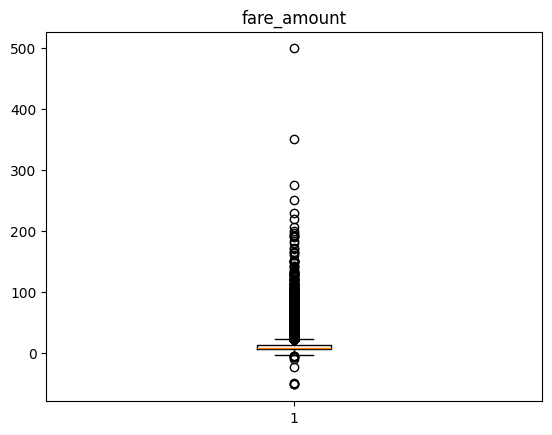

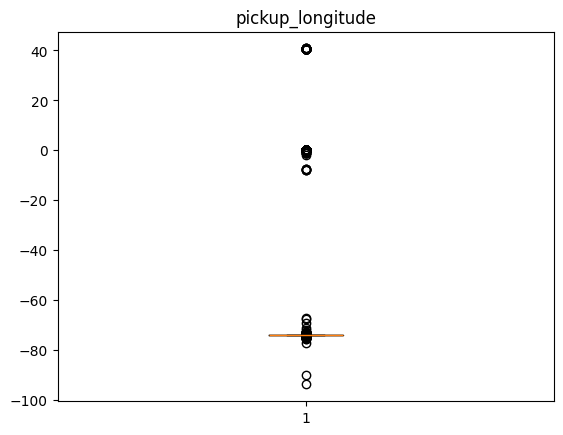

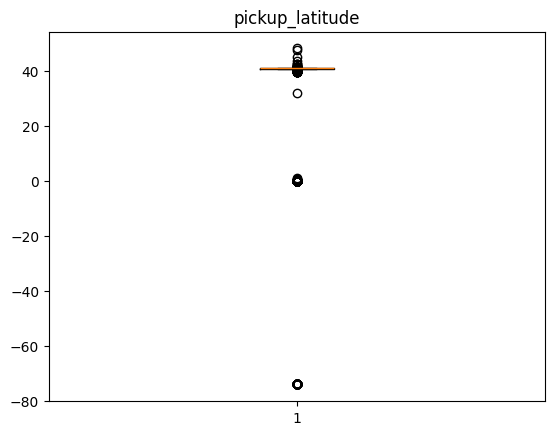

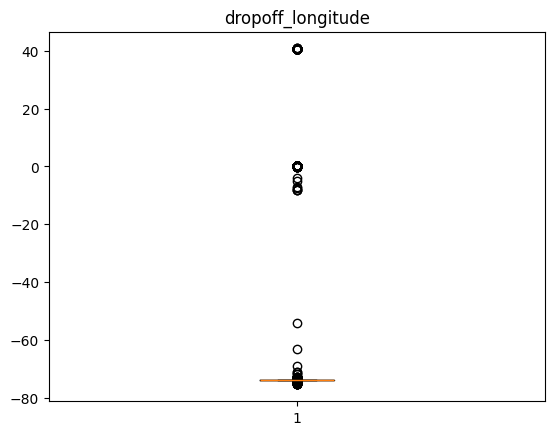

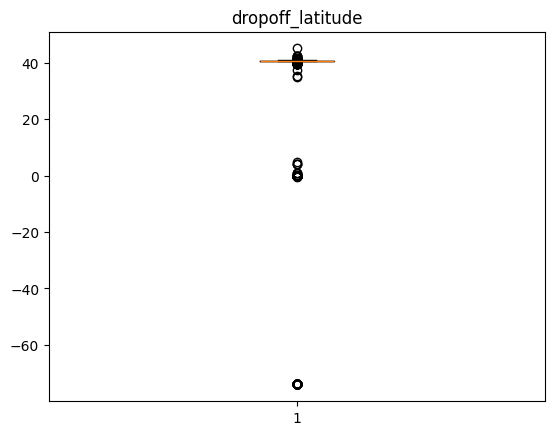

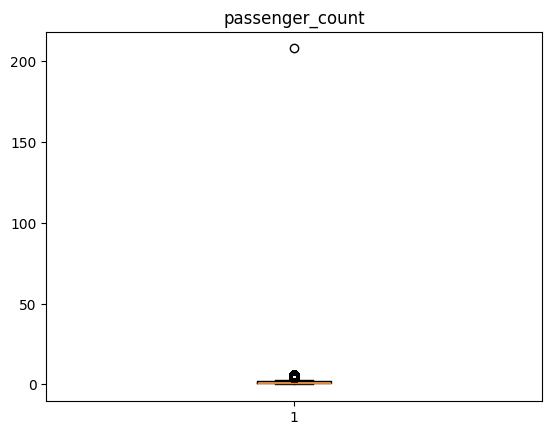

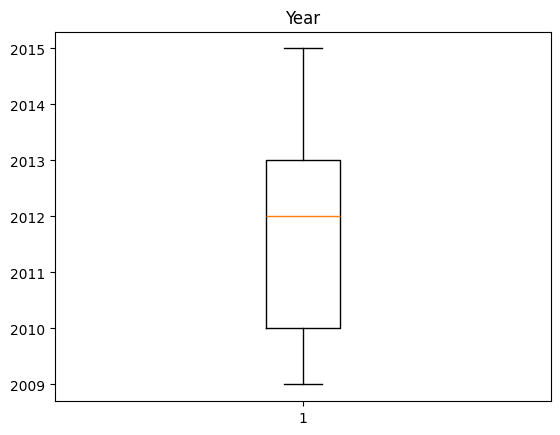

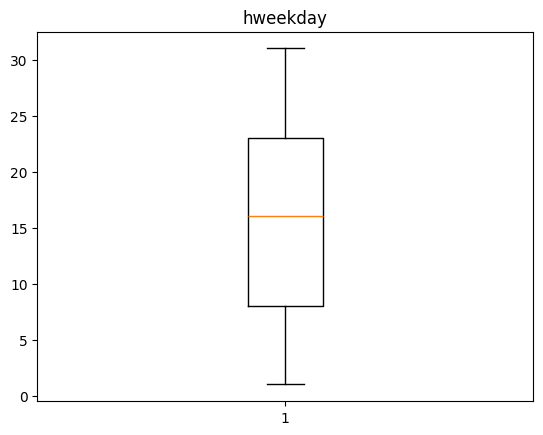

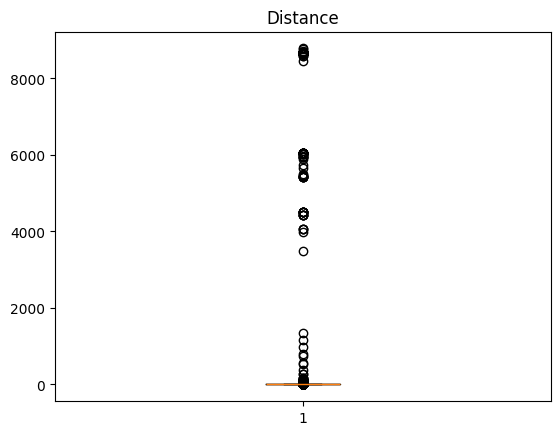

In [57]:
#outliers check
for i in df.columns:
  if (df[i].dtype != 'object' and df[i].dtype != "category"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [58]:
df.columns

Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'Year',
       'hweekday', 'Houraly_Segmentation', 'Distance'],
      dtype='object')

In [59]:
for i in df.columns:
  if(df[i].dtype != "object" and df[i].dtype != "category"):
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    LB = Q1-1.5*IQR
    UB = Q3+1.5*IQR
    df = df[(df[i]>=LB) & (df[i]<=UB)]

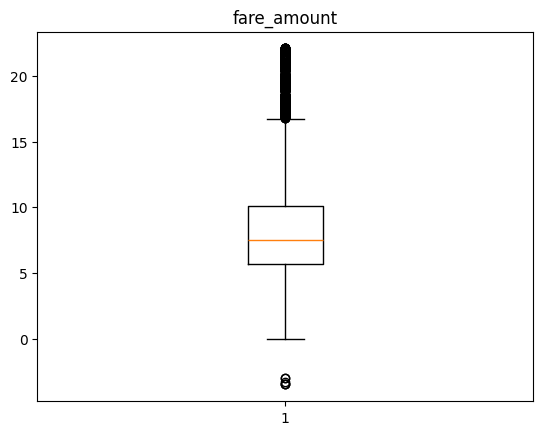

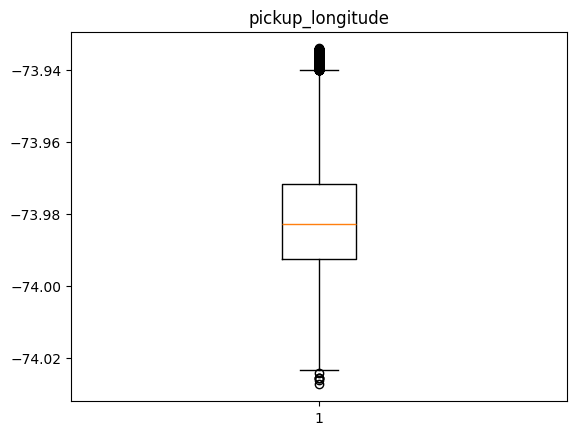

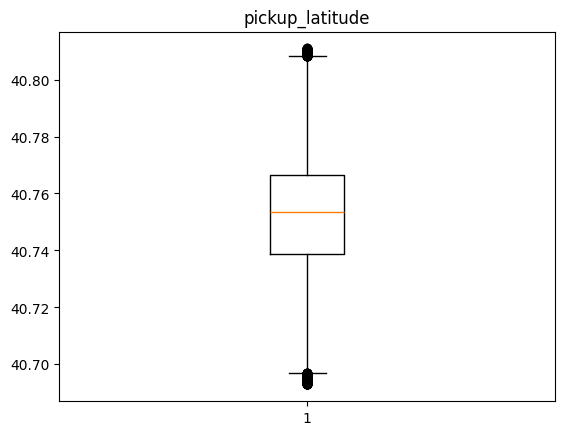

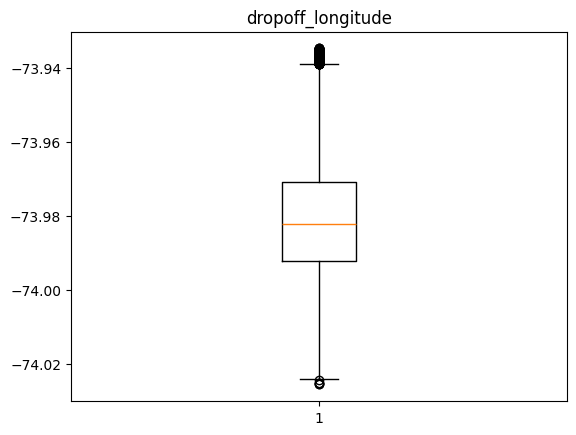

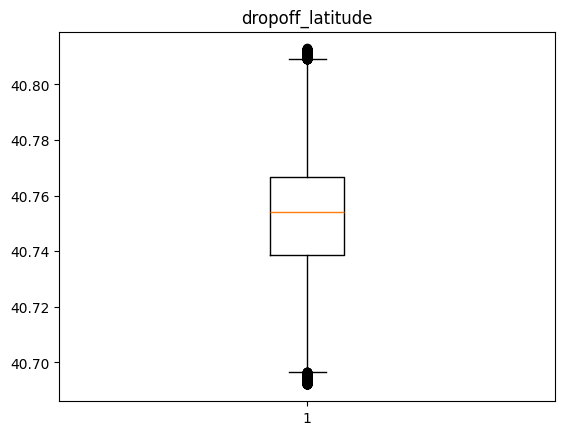

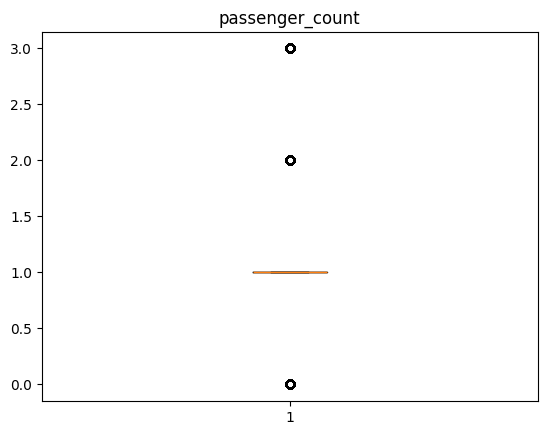

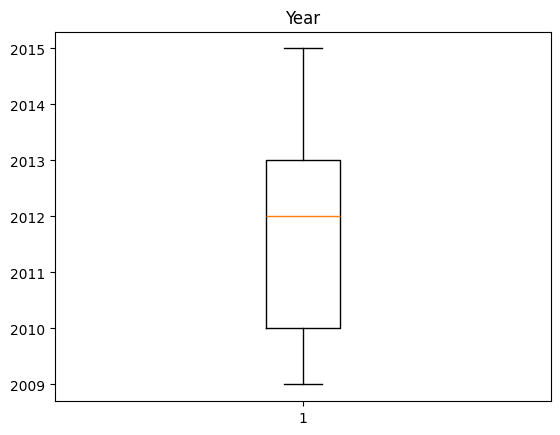

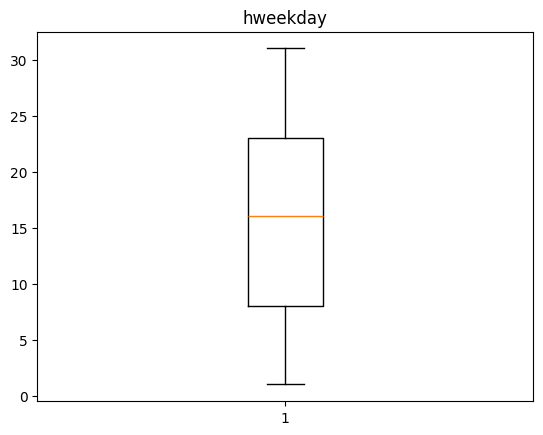

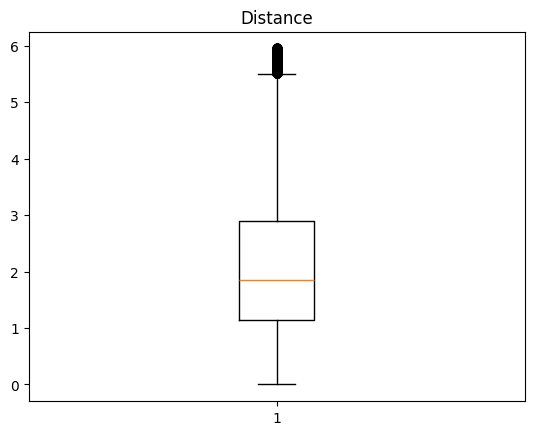

In [60]:
for i in df.columns:
  if(df[i].dtype != "object" and df[i].dtype != "category"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [61]:
df["fare_amount"].unique()

array([ 7.500e+00,  7.700e+00,  1.290e+01,  5.300e+00,  4.900e+00,
        9.700e+00,  1.250e+01,  6.500e+00,  1.090e+01,  6.900e+00,
        1.050e+01,  1.200e+01,  5.000e+00,  4.100e+00,  9.500e+00,
        1.100e+01,  8.100e+00,  5.700e+00,  1.570e+01,  9.000e+00,
        5.400e+00,  3.300e+00,  8.900e+00,  1.700e+01,  1.350e+01,
        1.330e+01,  1.690e+01,  1.730e+01,  2.000e+01,  1.300e+01,
        5.500e+00,  1.550e+01,  8.500e+00,  2.100e+01,  1.130e+01,
        3.500e+00,  7.300e+00,  9.300e+00,  3.700e+00,  4.000e+00,
        4.500e+00,  6.000e+00,  1.010e+01,  6.100e+00,  1.000e+01,
        1.500e+01,  8.000e+00,  1.800e+01,  1.370e+01,  8.200e+00,
        2.200e+01,  1.450e+01,  7.000e+00,  1.150e+01,  1.410e+01,
        1.400e+01,  1.170e+01,  1.210e+01,  1.600e+01,  1.900e+01,
        1.770e+01,  1.650e+01,  1.490e+01,  8.300e+00,  1.530e+01,
        2.130e+01,  2.050e+01,  3.000e+00,  1.610e+01,  1.930e+01,
        1.804e+01,  9.800e+00,  6.200e+00,  1.750e+01,  1.420e

In [62]:
df=df.loc[(df.fare_amount > 0)]

In [63]:
df["Distance"].unique()

array([1.68, 2.45, 5.04, 1.66, 0.  , 2.34, 4.89, 2.25, 3.58, 1.31, 1.72,
       0.73, 2.52, 1.79, 1.03, 2.49, 0.96, 1.26, 1.75, 2.73, 0.72, 3.23,
       1.43, 1.9 , 1.91, 3.18, 2.93, 1.2 , 2.64, 4.82, 1.25, 0.8 , 0.84,
       0.39, 2.43, 3.13, 3.73, 4.5 , 1.56, 4.92, 4.52, 1.18, 1.29, 1.21,
       0.87, 2.11, 5.9 , 0.69, 5.63, 0.75, 5.84, 3.09, 2.07, 3.32, 0.51,
       1.95, 4.58, 4.24, 0.91, 2.5 , 0.42, 2.95, 1.3 , 1.81, 1.36, 1.4 ,
       1.09, 1.23, 2.18, 0.59, 0.71, 0.57, 0.99, 1.7 , 2.21, 0.83, 1.76,
       3.21, 1.47, 1.97, 3.74, 1.22, 1.16, 2.12, 1.57, 1.01, 3.51, 3.77,
       5.06, 4.71, 1.71, 1.19, 1.64, 3.08, 1.37, 3.48, 1.02, 3.61, 0.92,
       3.44, 1.17, 0.85, 1.49, 0.58, 2.62, 1.52, 3.9 , 1.32, 2.32, 2.33,
       3.62, 1.06, 0.95, 3.66, 5.74, 1.41, 2.04, 4.45, 1.14, 0.44, 3.  ,
       1.69, 3.24, 1.82, 1.15, 1.8 , 1.13, 3.06, 0.76, 4.61, 0.88, 1.27,
       3.07, 0.78, 1.83, 2.27, 3.29, 2.53, 5.15, 1.05, 0.94, 4.01, 3.4 ,
       1.86, 1.78, 1.11, 1.53, 5.67, 2.06, 2.97, 1.

In [64]:
df= df.loc[(df.Distance>0)]

In [65]:
df

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,hweekday,Houraly_Segmentation,Distance
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,7,H6,1.68
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,17,H6,2.45
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,24,H6,5.04
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,26,H3,1.66
8,9.7,-73.975187,40.745767,-74.002720,40.743537,1,2012,17,H4,2.34
...,...,...,...,...,...,...,...,...,...,...
199994,12.0,-73.983070,40.760770,-73.972972,40.754177,1,2014,31,H5,1.12
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,2012,28,H4,0.11
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,2014,14,H1,1.88
199998,14.5,-73.997124,40.725452,-73.983215,40.695415,1,2015,20,H5,3.54


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140735 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   fare_amount           140735 non-null  float64 
 1   pickup_longitude      140735 non-null  float64 
 2   pickup_latitude       140735 non-null  float64 
 3   dropoff_longitude     140735 non-null  float64 
 4   dropoff_latitude      140735 non-null  float64 
 5   passenger_count       140735 non-null  int64   
 6   Year                  140735 non-null  int32   
 7   hweekday              140735 non-null  int32   
 8   Houraly_Segmentation  140735 non-null  category
 9   Distance              140735 non-null  float64 
dtypes: category(1), float64(6), int32(2), int64(1)
memory usage: 9.8 MB


In [69]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Houraly_Segmentation"] = le.fit_transform(df["Houraly_Segmentation"])

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140735 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   fare_amount           140735 non-null  float64
 1   pickup_longitude      140735 non-null  float64
 2   pickup_latitude       140735 non-null  float64
 3   dropoff_longitude     140735 non-null  float64
 4   dropoff_latitude      140735 non-null  float64
 5   passenger_count       140735 non-null  int64  
 6   Year                  140735 non-null  int32  
 7   hweekday              140735 non-null  int32  
 8   Houraly_Segmentation  140735 non-null  int64  
 9   Distance              140735 non-null  float64
dtypes: float64(6), int32(2), int64(2)
memory usage: 10.7 MB


In [71]:
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [72]:
x=df.drop(columns="fare_amount")
y=df["fare_amount"]

x_test,x_train,y_test,y_train = train_test_split(x,y,test_size=0.2,random_state=42)


In [73]:
base_estimator = RandomForestRegressor()

bagging = BaggingRegressor(
    base_estimator,
    n_estimators = 10,
    max_samples = 1.0,
    max_features = 1.0,
    bootstrap=True
)

bagging.fit(x_train, y_train)

y_pred = bagging.predict(x_test)

print("R2 Score", r2_score(y_test, y_pred))


R2 Score 0.6992623180871933
